In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

import joblib

print("✅ Tous les imports OK")

C:\Users\suki\AppData\Local\Temp\ipykernel_20376\3726921650.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Tous les imports OK


In [2]:
df = pd.read_csv('../data/processed/reclamations_clean.csv')

print(f"Dataset : {len(df)} réclamations")
print(f"\nDistribution des catégories :")
print(df['categorie'].value_counts())
print(f"\nDistribution des priorités :")
print(df['priorite'].value_counts())

Dataset : 1108 réclamations

Distribution des catégories :
categorie
retard_livraison         200
probleme_transport       200
erreur_picking           200
produit_casse            198
mauvaise_qualite         198
erreur_administrative    100
article_manquant          12
Name: count, dtype: int64

Distribution des priorités :
priorite
moyenne     439
elevee      369
faible      155
critique    145
Name: count, dtype: int64


In [3]:
# X = les textes (entrée du modèle)
X = df['texte_clean']

# y = les catégories (ce qu'on veut prédire)
y = df['categorie']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nCatégories uniques : {y.unique()}")
print(f"Nombre de catégories : {y.nunique()}")

X shape : (1108,)
y shape : (1108,)

Catégories uniques : ['erreur_administrative' 'produit_casse' 'retard_livraison'
 'article_manquant' 'mauvaise_qualite' 'probleme_transport'
 'erreur_picking']
Nombre de catégories : 7


In [4]:
# 80% pour entraîner, 20% pour tester
# stratify=y → garde la même distribution des catégories dans train et test
# random_state=42 → pour avoir le même résultat à chaque exécution

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Données d'entraînement : {len(X_train)} réclamations")
print(f"Données de test : {len(X_test)} réclamations")
print(f"\nDistribution dans train :")
print(y_train.value_counts())
print(f"\nDistribution dans test :")
print(y_test.value_counts())

Données d'entraînement : 886 réclamations
Données de test : 222 réclamations

Distribution dans train :
categorie
retard_livraison         160
erreur_picking           160
probleme_transport       160
mauvaise_qualite         158
produit_casse            158
erreur_administrative     80
article_manquant          10
Name: count, dtype: int64

Distribution dans test :
categorie
produit_casse            40
mauvaise_qualite         40
probleme_transport       40
erreur_picking           40
retard_livraison         40
erreur_administrative    20
article_manquant          2
Name: count, dtype: int64


In [5]:
# Créer le vectoriseur
vectorizer = TfidfVectorizer(
    max_features=5000,       # garder les 5000 mots les plus importants
    ngram_range=(1, 2),      # mots seuls ET groupes de 2 mots
    min_df=2,                # ignorer les mots qui apparaissent dans moins de 2 documents
    max_df=0.95              # ignorer les mots qui apparaissent dans plus de 95% des documents
)

# Entraîner sur le train et transformer
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Matrice train : {X_train_vec.shape}")  # (nb_textes, nb_features)
print(f"Matrice test  : {X_test_vec.shape}")
print(f"\nNombre de features (mots) : {len(vectorizer.get_feature_names_out())}")

# Voir quelques features apprises
print(f"\nExemple de features : {vectorizer.get_feature_names_out()[100:120]}")

Matrice train : (886, 5000)
Matrice test  : (222, 5000)

Nombre de features (mots) : 5000

Exemple de features : ['adresse nom' 'adresse numero' 'adresse physique' 'adresse postal'
 'adresse precedent' 'adresse rapport' 'adresse signale' 'adresse voir'
 'adresse vouloir' 'adresse xxxxxxx' 'aerienn' 'affaire' 'affectee'
 'affectee court' 'affectee negativement' 'affecter' 'affecter frauduleux'
 'affecter negativement' 'affecter sante' 'affiche']


In [6]:
# Créer le modèle
modele = LogisticRegression(
    max_iter=1000,                # nombre max d'itérations
    class_weight='balanced',      # gérer le déséquilibre des classes
    random_state=42,
    C=1.0                          # paramètre de régularisation (1.0 = défaut)
)

# Entraîner !
print("Entraînement en cours...")
modele.fit(X_train_vec, y_train)
print("✅ Modèle entraîné !")

Entraînement en cours...
✅ Modèle entraîné !


In [7]:
# Prédire sur le test set
y_pred = modele.predict(X_test_vec)

# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy sur le test : {accuracy*100:.2f}%")

🎯 Accuracy sur le test : 78.83%


In [9]:
# Importer le même preprocessing que dans le notebook 05
import spacy
import unicodedata
import re

nlp = spacy.load("fr_core_news_md")

def normaliser_texte(texte):
    texte = str(texte).lower().strip()
    texte = unicodedata.normalize('NFKD', texte)
    texte = ''.join([c for c in texte if not unicodedata.combining(c)])
    return texte

def nettoyer_texte(texte):
    texte = re.sub(r'[^\w\s]', ' ', texte)
    texte = re.sub(r'\d+', ' ', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

def lemmatiser_texte(texte):
    doc = nlp(texte)
    tokens = []
    for token in doc:
        if (not token.is_stop and not token.is_punct 
            and len(token.text) > 2 and token.is_alpha):
            tokens.append(token.lemma_)
    return ' '.join(tokens)

def preprocesser_complet(texte):
    """LE MÊME preprocessing que pour l'entraînement !"""
    texte = normaliser_texte(texte)
    texte = nettoyer_texte(texte)
    texte = lemmatiser_texte(texte)
    return texte


def predire_reclamation(texte):
    """Prédit la catégorie d'une nouvelle réclamation."""
    # 🔑 Utiliser EXACTEMENT le même preprocessing que l'entraînement
    texte_clean = preprocesser_complet(texte)
    
    # Vectoriser
    texte_vec = vectorizer.transform([texte_clean])
    
    # Prédire
    prediction = modele.predict(texte_vec)[0]
    probas = modele.predict_proba(texte_vec)[0]
    confiance = max(probas)
    
    return prediction, confiance


# Re-tester
exemples = [
    "mon colis n'est jamais arrivé après trois semaines d'attente",
    "le produit est complètement cassé en arrivant",
    "j'ai reçu le mauvais article",  # version plus claire
    "il manque la moitié de ma commande",  # séparé
    "la qualité du produit est très décevante médiocre",
]

for ex in exemples:
    pred, conf = predire_reclamation(ex)
    print(f"\nTexte : {ex}")
    print(f"→ Catégorie : {pred}")
    print(f"→ Confiance : {conf*100:.1f}%")


Texte : mon colis n'est jamais arrivé après trois semaines d'attente
→ Catégorie : retard_livraison
→ Confiance : 24.7%

Texte : le produit est complètement cassé en arrivant
→ Catégorie : mauvaise_qualite
→ Confiance : 21.9%

Texte : j'ai reçu le mauvais article
→ Catégorie : probleme_transport
→ Confiance : 38.7%

Texte : il manque la moitié de ma commande
→ Catégorie : produit_casse
→ Confiance : 19.2%

Texte : la qualité du produit est très décevante médiocre
→ Catégorie : mauvaise_qualite
→ Confiance : 29.6%


In [10]:
def predire_reclamation(texte):
    """Prédit la catégorie d'une nouvelle réclamation."""
    # Important : il faut aussi nettoyer ce texte !
    import sys
    sys.path.append('..')
    
    # Pour cet exemple, on simule un nettoyage simple
    texte_clean = texte.lower()
    
    # Vectoriser
    texte_vec = vectorizer.transform([texte_clean])
    
    # Prédire
    prediction = modele.predict(texte_vec)[0]
    probas = modele.predict_proba(texte_vec)[0]
    confiance = max(probas)
    
    return prediction, confiance

# Tester avec quelques exemples
exemples = [
    "mon colis n'est jamais arrive apres trois semaines d'attente",
    "le produit est completement casse en arrivant",
    "j'ai recu le mauvais article il manque la moitie de ma commande",
    "la qualite du produit est tres decevante mediocre",
]

for ex in exemples:
    pred, conf = predire_reclamation(ex)
    print(f"\nTexte : {ex}")
    print(f"→ Catégorie prédite : {pred} (confiance : {conf*100:.1f}%)")


Texte : mon colis n'est jamais arrive apres trois semaines d'attente
→ Catégorie prédite : retard_livraison (confiance : 24.1%)

Texte : le produit est completement casse en arrivant
→ Catégorie prédite : produit_casse (confiance : 24.7%)

Texte : j'ai recu le mauvais article il manque la moitie de ma commande
→ Catégorie prédite : probleme_transport (confiance : 23.5%)

Texte : la qualite du produit est tres decevante mediocre
→ Catégorie prédite : mauvaise_qualite (confiance : 29.6%)


In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = modele.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy globale sur le test : {accuracy*100:.2f}%")
print(f"\n📊 Détails par catégorie :")
print(classification_report(y_test, y_pred))

🎯 Accuracy globale sur le test : 78.83%

📊 Détails par catégorie :
                       precision    recall  f1-score   support

     article_manquant       1.00      1.00      1.00         2
erreur_administrative       0.62      0.80      0.70        20
       erreur_picking       1.00      0.85      0.92        40
     mauvaise_qualite       0.72      0.82      0.77        40
   probleme_transport       0.89      0.85      0.87        40
        produit_casse       0.79      0.65      0.71        40
     retard_livraison       0.70      0.75      0.72        40

             accuracy                           0.79       222
            macro avg       0.82      0.82      0.81       222
         weighted avg       0.80      0.79      0.79       222



In [12]:
def predire_avec_details(texte):
    """Montre toutes les probabilités."""
    texte_clean = preprocesser_complet(texte)
    texte_vec = vectorizer.transform([texte_clean])
    
    probas = modele.predict_proba(texte_vec)[0]
    classes = modele.classes_
    
    # Trier les catégories par probabilité décroissante
    resultats = sorted(zip(classes, probas), key=lambda x: -x[1])
    
    print(f"\n📝 Texte : {texte}")
    print(f"🧹 Après nettoyage : {texte_clean}")
    print(f"\n📊 Probabilités :")
    for cat, prob in resultats:
        barre = '█' * int(prob * 30)
        print(f"   {cat:25s} {prob*100:5.1f}% {barre}")


# Tester
predire_avec_details("mon colis n'est jamais arrivé après trois semaines d'attente")
predire_avec_details("le produit est complètement cassé en arrivant")


📝 Texte : mon colis n'est jamais arrivé après trois semaines d'attente
🧹 Après nettoyage : colis jamais arriver semaine attente

📊 Probabilités :
   retard_livraison           24.7% ███████
   mauvaise_qualite           19.9% █████
   produit_casse              18.0% █████
   probleme_transport         15.3% ████
   erreur_administrative       9.7% ██
   article_manquant            7.3% ██
   erreur_picking              5.2% █

📝 Texte : le produit est complètement cassé en arrivant
🧹 Après nettoyage : produit completement casser arriver

📊 Probabilités :
   mauvaise_qualite           21.9% ██████
   produit_casse              19.4% █████
   retard_livraison           18.8% █████
   probleme_transport         16.2% ████
   erreur_administrative      13.2% ███
   erreur_picking              5.4% █
   article_manquant            5.2% █


In [13]:
from sklearn.metrics import classification_report

# (Recharge les variables nécessaires : modele, X_test_vec, y_test, y_pred)
# Si tu es dans un notebook séparé, refais les étapes du notebook 06 d'abord
# Ou utilise %store -r pour récupérer les variables

print("=" * 70)
print("RAPPORT DE CLASSIFICATION COMPLET")
print("=" * 70)
print(classification_report(y_test, y_pred))

RAPPORT DE CLASSIFICATION COMPLET
                       precision    recall  f1-score   support

     article_manquant       1.00      1.00      1.00         2
erreur_administrative       0.62      0.80      0.70        20
       erreur_picking       1.00      0.85      0.92        40
     mauvaise_qualite       0.72      0.82      0.77        40
   probleme_transport       0.89      0.85      0.87        40
        produit_casse       0.79      0.65      0.71        40
     retard_livraison       0.70      0.75      0.72        40

             accuracy                           0.79       222
            macro avg       0.82      0.82      0.81       222
         weighted avg       0.80      0.79      0.79       222



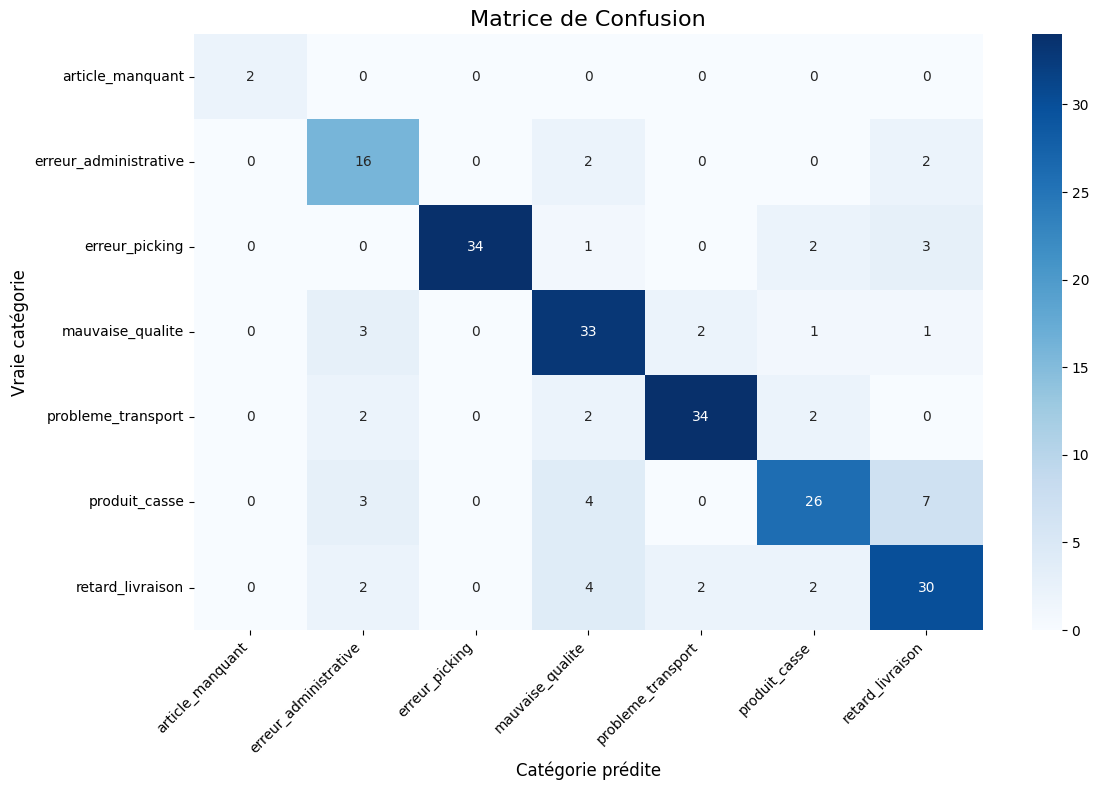

In [14]:
from sklearn.metrics import confusion_matrix

# Calculer la matrice
cm = confusion_matrix(y_test, y_pred, labels=modele.classes_)

# Visualiser
plt.figure(figsize=(12, 8))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=modele.classes_,
            yticklabels=modele.classes_)
plt.title('Matrice de Confusion', fontsize=16)
plt.ylabel('Vraie catégorie', fontsize=12)
plt.xlabel('Catégorie prédite', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# Trouver les cas où le modèle s'est trompé
df_test = pd.DataFrame({
    'texte': X_test.values,
    'vraie_categorie': y_test.values,
    'prediction': y_pred
})

erreurs = df_test[df_test['vraie_categorie'] != df_test['prediction']]
print(f"Nombre total d'erreurs : {len(erreurs)} sur {len(df_test)}")
print(f"Taux d'erreur : {len(erreurs)/len(df_test)*100:.1f}%")

print("\nQuelques exemples d'erreurs :")
for i in range(min(5, len(erreurs))):
    row = erreurs.iloc[i]
    print(f"\n--- Erreur {i+1} ---")
    print(f"Texte : {row['texte'][:150]}...")
    print(f"Vraie catégorie : {row['vraie_categorie']}")
    print(f"Prédiction : {row['prediction']}")

Nombre total d'erreurs : 47 sur 222
Taux d'erreur : 21.2%

Quelques exemples d'erreurs :

--- Erreur 1 ---
Texte : rapport echoue compte excellent statut provoquer baisse score fico envoye notification fcra erreur assuree erreur corrigee jamais corrigee date hier v...
Vraie catégorie : produit_casse
Prédiction : erreur_administrative

--- Erreur 2 ---
Texte : aujourd capital aide pretendument sauter paiement pretendumer defenseur client trouver condescendre humiliant definition opposee avocat femme extremem...
Vraie catégorie : mauvaise_qualite
Prédiction : retard_livraison

--- Erreur 3 ---
Texte : loancare llc fournir declaration remboursement hypotheque joindre frais interdire reglement cfr frais releve loancare fournir divulgation frais traite...
Vraie catégorie : probleme_transport
Prédiction : erreur_administrative

--- Erreur 4 ---
Texte : programme remboursement actuellement progressif pret etudiant sallie ma payer generalement mois retard actuellement mois dernier paiement moi

In [16]:
import numpy as np

# Pour chaque catégorie, voir les mots qui pèsent le plus
feature_names = vectorizer.get_feature_names_out()

for i, categorie in enumerate(modele.classes_):
    # Coefficients du modèle pour cette catégorie
    coefs = modele.coef_[i]
    # Top 10 mots avec les coefficients les plus élevés
    top_indices = np.argsort(coefs)[-10:][::-1]
    top_mots = [feature_names[idx] for idx in top_indices]
    
    print(f"\n📌 {categorie} :")
    print(f"   Mots-clés : {', '.join(top_mots)}")


📌 article_manquant :
   Mots-clés : manquant, article, marchandise, article manquant, manquer, article manquer, commande, manquant rapport, inexact liste, jour element

📌 erreur_administrative :
   Mots-clés : facturation, erreur facturation, erreur, double, frais, charge, frais double, releve, transaction, payer

📌 erreur_picking :
   Mots-clés : incorrect, article incorrect, article, incorrect rapport, resultat, resultat enquete, enquete, litige depose, rapport, depose

📌 mauvaise_qualite :
   Mots-clés : faux, argent, defectueux, fraude, compte, numero, banque, faux compte, cheque, nom

📌 probleme_transport :
   Mots-clés : adresse, mauvais adresse, mauvais, assurance, transporteur, compagnie, compagnie assurance, equifax, envoye, adresse correct

📌 produit_casse :
   Mots-clés : endommager, propriete, detruit, casse, credit, enfreindre, taux, essayer, inexact rapport, loi

📌 retard_livraison :
   Mots-clés : retard, tard, paiement, retard paiement, paiement retard, pret, preuve, j